# Classifying Potentially Hazardous Asteroids from NASA JPL Orbital Data Using Supervised Machine Learning

**Machine Learning Term Project, Group 16**

| Name | UF Email | Role |
|---|---|---|
| Leonardo Rodrigues Fabbro | lrodriguesfabbro@ufl.edu | Team Leader |
| Madhurishitha Boddu | mboddu@ufl.edu | Member |
| Kunal Sharma | sharmaKunal@ufl.edu | Member |
| Shunmuka Valsa | shunmukavalsa@ufl.edu | Member |

## 1.1 Problem statement

The NASA Jet Propulsion Laboratory designates a subset of catalogued asteroids as
Potentially Hazardous Asteroids (PHAs). The designation applies to fewer than one percent
of objects in the Small-Body Database. This project investigates whether the designation
can be predicted from orbital and physical parameters using supervised machine learning,
and whether predictive performance is retained once the parameters that define the
designation are withheld from the models.

The task is binary classification. The target variable is `pha`, originally encoded Y or N
and mapped to 1 and 0 respectively.

## 1.2 Notebook organisation and individual contributions

Each section is attributed to a single author, who implemented the code in that section.
The coding workload is distributed evenly at eight code cells per author.

| Author | Sections | Code cells |
|---|---|---|
| Leonardo Rodrigues Fabbro | 3 data acquisition and quality assessment, 11 conclusions | 8 |
| Madhurishitha Boddu | 4 exploratory data analysis, 8 evaluation, 10 comparison | 8 |
| Shunmuka Valsa | 6 outlier analysis, partitioning and preprocessing, 9 experiment C | 8 |
| Kunal Sharma | 7 model implementation and tuning, 9 importance and experiment B | 8 |

## 1.3 Experimental design

Three experiments are conducted on identical train and test partitions.

| Experiment | Feature set | Research question |
|---|---|---|
| A | All available features | Can the JPL designation be reproduced from catalogue data? |
| B | Excluding `moid`, `moid_ld`, `H` | Is the designation recoverable without its defining parameters? |
| C | Also excluding `orbit_class`, `neo` | Does predictive signal remain in the orbital elements alone? |

---
## 2. Environment and configuration

The dataset is the NASA JPL Small-Body Database asteroid catalogue, obtained from
https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset. The CSV file is expected at
the path given by `DATA_PATH`.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "dataset.csv"

# Fixed seed applied to all stochastic operations to ensure reproducibility.
RANDOM_STATE = 42

# Size of the stratified sample drawn from the catalogue. Random Forest fitting time scales
# poorly with sample size, so a subsample is used to keep the full workflow tractable on
# standard hardware. Set to None to train on the complete catalogue.
SAMPLE_ROWS = 150_000

# Size of the stratified slice of the training partition used for cross validation and
# hyperparameter search.
TUNE_ROWS = 30_000

print("Configuration loaded. pandas", pd.__version__)

Configuration loaded. pandas 2.3.3


---
## 3. Data acquisition and quality assessment

**Author: Leonardo Rodrigues Fabbro**

This section loads the catalogue, removes non-predictive columns, resolves the target
variable, and documents the completeness of each field.

Each cell assigns a distinct dataframe name rather than reassigning a single variable.
This makes the section idempotent under repeated or non-sequential cell execution.

In [2]:
raw = pd.read_csv(DATA_PATH, low_memory=False)

print("Records:", f"{len(raw):,}")
print("Columns:", raw.shape[1])

# Verify the expected schema before any downstream processing depends on it.
expected = ["pha", "neo", "class", "moid", "H", "a", "e", "i", "q"]
absent = [c for c in expected if c not in raw.columns]
if absent:
    print("Missing expected columns:", absent)
    print("Columns present:", raw.columns.tolist())
else:
    print("Schema verified.")

raw.head()

Records: 958,524
Columns: 45
Schema verified.


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,albedo,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,58600,20190427.0,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,59000,20200531.0,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,59000,20200531.0,J2000,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,2.018112e+07,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,58600,20190427.0,J2000,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,2.018051e+07,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,59000,20200531.0,J2000,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,2.020032e+07,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [3]:
# Data dictionary for the retained fields.
column_notes = {
    "a": "Semi-major axis (au)",
    "e": "Eccentricity",
    "i": "Inclination to the ecliptic (degrees)",
    "q": "Perihelion distance (au)",
    "ad": "Aphelion distance (au)",
    "om": "Longitude of the ascending node (degrees)",
    "w": "Argument of perihelion (degrees)",
    "ma": "Mean anomaly (degrees)",
    "n": "Mean motion (degrees per day)",
    "per": "Orbital period (days)",
    "per_y": "Orbital period (years)",
    "tp": "Time of perihelion passage (Julian date)",
    "epoch": "Epoch of the orbital solution (Julian date)",
    "moid": "Minimum orbit intersection distance with Earth (au)",
    "moid_ld": "Minimum orbit intersection distance with Earth (lunar distances)",
    "H": "Absolute magnitude",
    "diameter": "Measured diameter (km)",
    "albedo": "Geometric albedo",
    "diameter_sigma": "Uncertainty on the measured diameter (km)",
    "rms": "Root mean square residual of the orbit fit",
    "neo": "Near-Earth object indicator (Y or N)",
    "pha": "Potentially hazardous asteroid indicator (Y or N), target variable",
    "class": "Dynamical orbit classification",
}
pd.DataFrame(
    [(c, column_notes.get(c, "Uncertainty on the corresponding orbital element"))
     for c in raw.columns],
    columns=["Column", "Description"],
)

,Column,Description
0,id,Uncertainty on the corresponding orbital element
1,spkid,Uncertainty on the corresponding orbital element
2,full_name,Uncertainty on the corresponding orbital element
3,pdes,Uncertainty on the corresponding orbital element
4,name,Uncertainty on the corresponding orbital element
5,prefix,Uncertainty on the corresponding orbital element
6,neo,Near-Earth object indicator (Y or N)
7,pha,Potentially hazardous asteroid indicator (Y or...
8,H,Absolute magnitude
9,diameter,Measured diameter (km)


In [4]:
# Identifiers, designations and metadata carry no predictive information and are removed to
# prevent the models from fitting catalogue artefacts.
id_cols = ["id", "spkid", "full_name", "pdes", "name", "prefix", "orbit_id", "equinox"]

# Calendar-format duplicates of fields already present as Julian dates.
duplicate_date_cols = ["epoch_mjd", "epoch_cal", "tp_cal"]

drop_now = [c for c in id_cols + duplicate_date_cols if c in raw.columns]
df_trimmed = raw.drop(columns=drop_now)
print("Removed", len(drop_now), "columns:", drop_now)
print("Retained", df_trimmed.shape[1], "columns")

Removed 11 columns: ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id', 'equinox', 'epoch_mjd', 'epoch_cal', 'tp_cal']
Retained 34 columns


In [5]:
# 'class' shadows a Python keyword and is renamed for clarity.
df_named = df_trimmed.rename(columns={"class": "orbit_class"})

# Records without a defined target value cannot contribute to supervised training.
keep = df_named["pha"].isin(["Y", "N"])
df_labeled = df_named[keep].copy()
print("Removed", f"{(~keep).sum():,}", "records with an undefined target")

# Encode the target as a binary integer, where 1 denotes a potentially hazardous asteroid.
df_labeled["pha"] = (df_labeled["pha"] == "Y").astype(int)
print("Target encoded.")

Removed 19,921 records with an undefined target
Target encoded.


In [6]:
dupes = int(df_labeled.duplicated().sum())
print("Duplicate records:", dupes)
df_clean = df_labeled.drop_duplicates() if dupes else df_labeled

print("Shape:", df_clean.shape)
print("Hazardous:", f"{int(df_clean['pha'].sum()):,}")
print("Non-hazardous:", f"{int((1 - df_clean['pha']).sum()):,}")
print("Positive class proportion:", round(100 * df_clean["pha"].mean(), 3), "percent")

Duplicate records: 0
Shape: (938603, 34)
Hazardous: 2,066
Non-hazardous: 936,537
Positive class proportion: 0.22 percent


In [7]:
# Completeness assessment across all retained fields.
missing = pd.DataFrame({
    "Missing": df_clean.isna().sum(),
    "Percent missing": (100 * df_clean.isna().mean()).round(2),
}).sort_values("Percent missing", ascending=False)
missing_nonzero = missing[missing["Missing"] > 0]

print("Fields with missing values:", len(missing_nonzero), "of", df_clean.shape[1])
missing_nonzero

Fields with missing values: 21 of 34


,Missing,Percent missing
albedo,803500,85.61
diameter_sigma,802522,85.50
diameter,802394,85.49
H,6262,0.67
neo,4,0.00
ma,1,0.00
ad,4,0.00
per,4,0.00
per_y,1,0.00
sigma_e,1,0.00


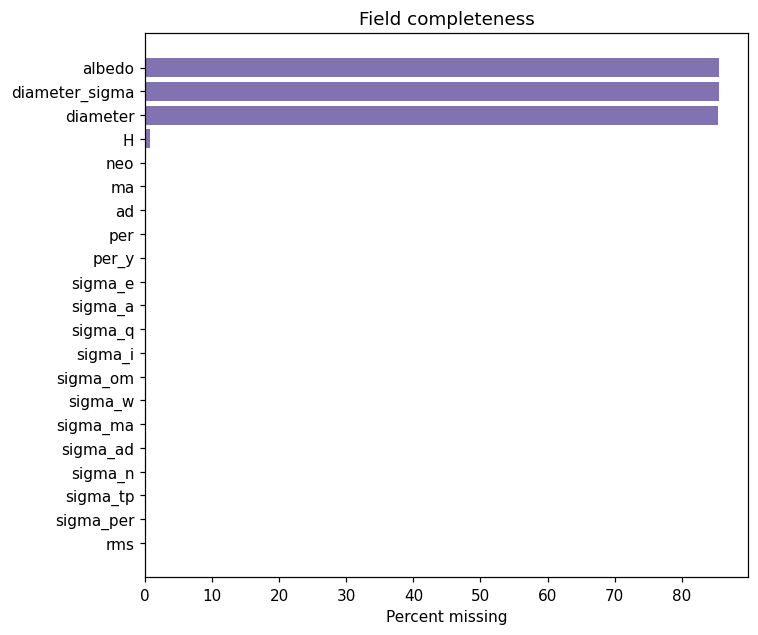

In [8]:
fig, ax = plt.subplots(figsize=(7, max(3, 0.28 * len(missing_nonzero))))
ax.barh(missing_nonzero.index[::-1], missing_nonzero["Percent missing"][::-1], color="#8172b2")
ax.set_xlabel("Percent missing")
ax.set_title("Field completeness")
plt.tight_layout()
plt.show()

The physical measurement fields (`diameter`, `albedo`, `diameter_sigma`) are absent for the
large majority of records. This reflects observational limitation rather than data corruption:
physical characterisation requires dedicated follow-up observation that has been performed for
only a small fraction of catalogued objects. These fields are retained and supplemented with
missingness indicators in Section 6, since the presence of a measurement is itself correlated
with observational priority.

In [9]:
# Stratified subsample preserving the class proportion. See SAMPLE_ROWS in Section 2.
if SAMPLE_ROWS is not None and SAMPLE_ROWS < len(df_clean):
    df_small, _ = train_test_split(
        df_clean, train_size=SAMPLE_ROWS, stratify=df_clean["pha"],
        random_state=RANDOM_STATE
    )
else:
    df_small = df_clean

df = df_small.reset_index(drop=True)
print("Analysis set:", f"{len(df):,}", "records,", int(df["pha"].sum()), "hazardous")

Analysis set: 150,000 records, 330 hazardous


---
## 4. Exploratory data analysis

**Author: Madhurishitha Boddu**

This section characterises the class distribution, compares the distributions of key orbital
parameters between classes, quantifies hazard prevalence across dynamical classes, and
examines collinearity among the orbital elements.

### 4.1 Class distribution

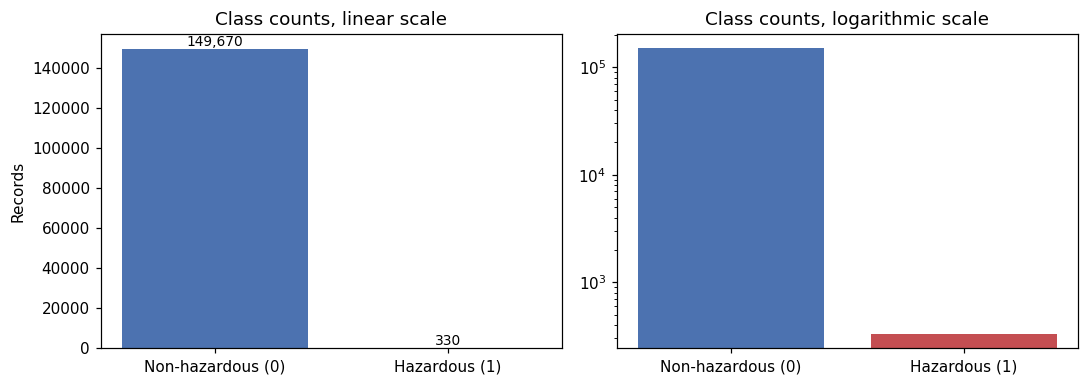

Positive class proportion: 0.22 percent
Majority-class baseline accuracy: 99.78 percent


In [10]:
counts = df["pha"].value_counts().sort_index()
labels = ["Non-hazardous (0)", "Hazardous (1)"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(labels, counts.values, color=["#4c72b0", "#c44e52"])
ax[0].set_title("Class counts, linear scale")
ax[0].set_ylabel("Records")
for j, v in enumerate(counts.values):
    ax[0].text(j, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

ax[1].bar(labels, counts.values, color=["#4c72b0", "#c44e52"])
ax[1].set_yscale("log")
ax[1].set_title("Class counts, logarithmic scale")
plt.tight_layout()
plt.show()

share = 100 * df["pha"].mean()
print("Positive class proportion:", round(share, 3), "percent")
print("Majority-class baseline accuracy:", round(100 - share, 3), "percent")

The majority-class baseline achieves high accuracy while identifying no hazardous objects.
Accuracy is therefore inappropriate as an evaluation metric for this problem. Section 8
reports precision, recall and F1 for the positive class, with average precision as the
primary threshold-independent metric.

### 4.2 Distribution of key orbital parameters by class

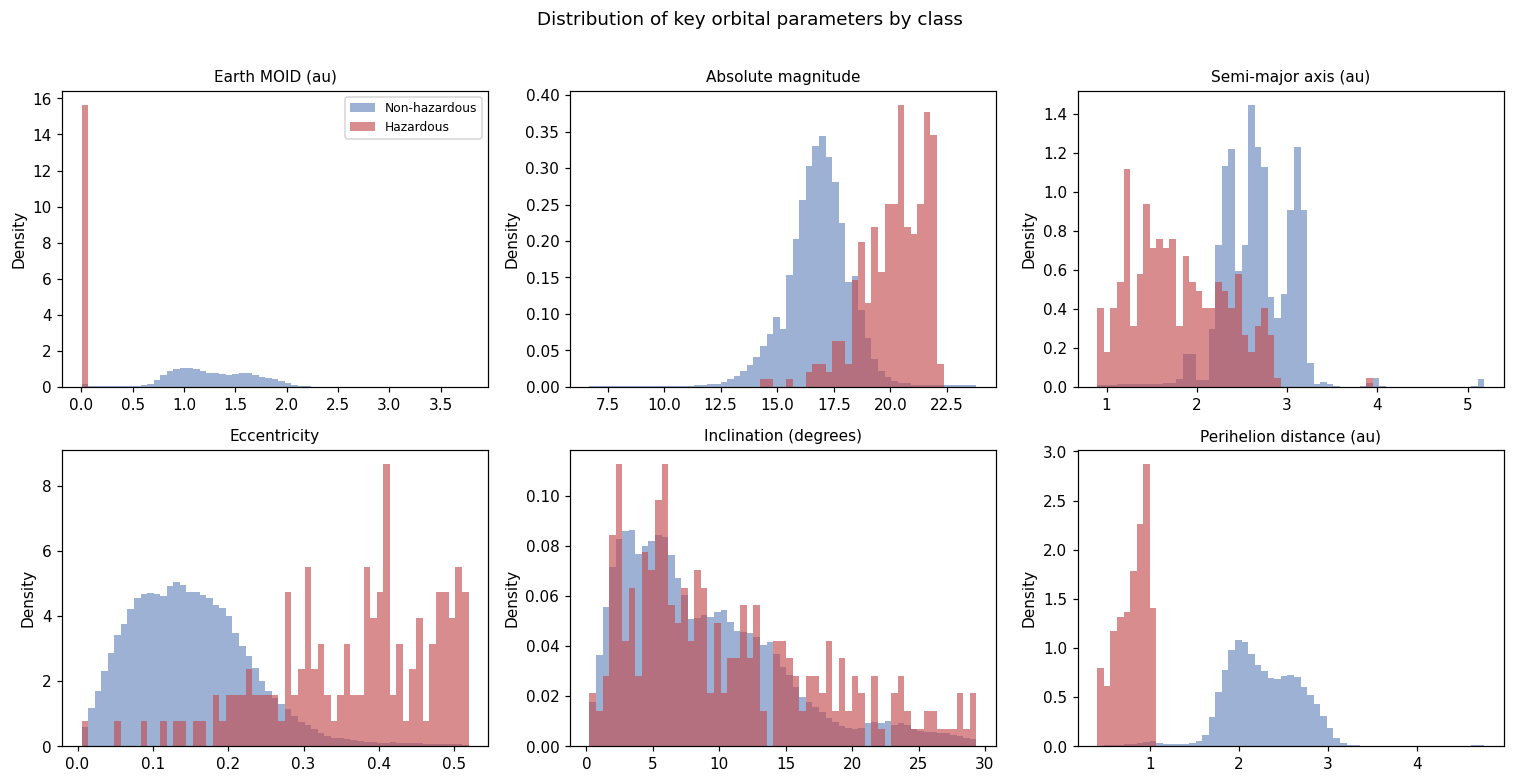

,Non-hazardous (median),Hazardous (median)
moid,1.245,0.023
H,16.900,20.400
a,2.649,1.672
e,0.144,0.552
i,7.426,9.978
q,2.231,0.805


In [11]:
key_features = ["moid", "H", "a", "e", "i", "q"]
nice_names = {
    "moid": "Earth MOID (au)",
    "H": "Absolute magnitude",
    "a": "Semi-major axis (au)",
    "e": "Eccentricity",
    "i": "Inclination (degrees)",
    "q": "Perihelion distance (au)",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key_features):
    safe = df[[col, "pha"]].dropna()
    # Bin range truncated at the 0.1 and 99 percentiles to limit distortion from extreme values.
    lo, hi = safe[col].quantile([0.001, 0.99])
    bins = np.linspace(lo, hi, 60)
    ax.hist(safe.loc[safe["pha"] == 0, col], bins=bins, density=True,
            alpha=0.55, label="Non-hazardous", color="#4c72b0")
    ax.hist(safe.loc[safe["pha"] == 1, col], bins=bins, density=True,
            alpha=0.65, label="Hazardous", color="#c44e52")
    ax.set_title(nice_names[col], fontsize=10)
    ax.set_ylabel("Density")

axes.ravel()[0].legend(fontsize=8)
plt.suptitle("Distribution of key orbital parameters by class", y=1.01)
plt.tight_layout()
plt.show()

medians = df.groupby("pha")[key_features].median().T
medians.columns = ["Non-hazardous (median)", "Hazardous (median)"]
medians.round(3)

The two classes separate most sharply on `moid` and `H`. The JPL criterion requires a minimum
orbit intersection distance below 0.05 au and an absolute magnitude of 22.0 or brighter, so
this separation is definitional rather than empirical. Experiments B and C in Sections 9 and 10
withhold these parameters to isolate the remaining predictive signal.

### 4.3 Hazard prevalence by dynamical class

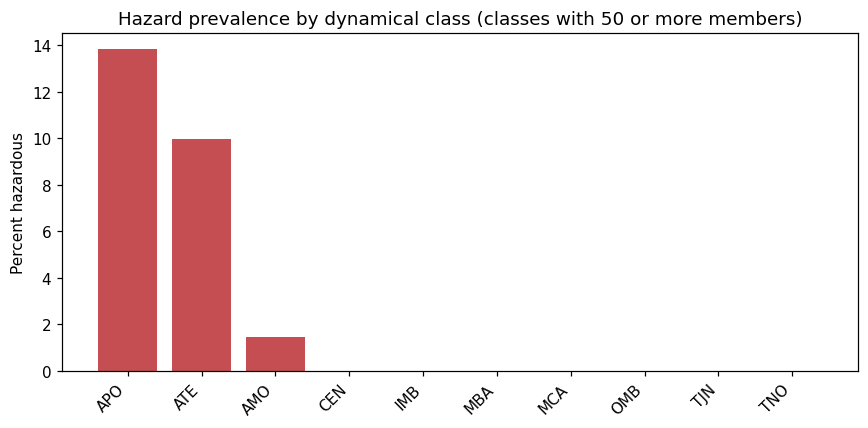

,Total,Hazardous,Percent hazardous
orbit_class,,,
IEO,3,1,33.333
APO,2024,280,13.834
ATE,301,30,9.967
AMO,1335,19,1.423
AST,14,0,0.000
CEN,81,0,0.000
HYA,1,0,0.000
IMB,3242,0,0.000
MBA,133730,0,0.000


In [12]:
by_class = df.groupby("orbit_class").agg(Total=("pha", "size"), Hazardous=("pha", "sum"))
by_class["Percent hazardous"] = (100 * by_class["Hazardous"] / by_class["Total"]).round(3)
by_class = by_class.sort_values("Percent hazardous", ascending=False)

show = by_class[by_class["Total"] >= 50]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(show.index, show["Percent hazardous"], color="#c44e52")
ax.set_ylabel("Percent hazardous")
ax.set_title("Hazard prevalence by dynamical class (classes with 50 or more members)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

by_class

Hazardous objects are confined almost entirely to the Apollo, Aten and Amor classes, which are
defined by Earth-crossing or Earth-approaching orbits. Main-belt classes exhibit zero
prevalence. The `orbit_class` field therefore encodes substantial target information
independently of the orbital elements, which motivates Experiment C.

### 4.4 Collinearity among orbital elements

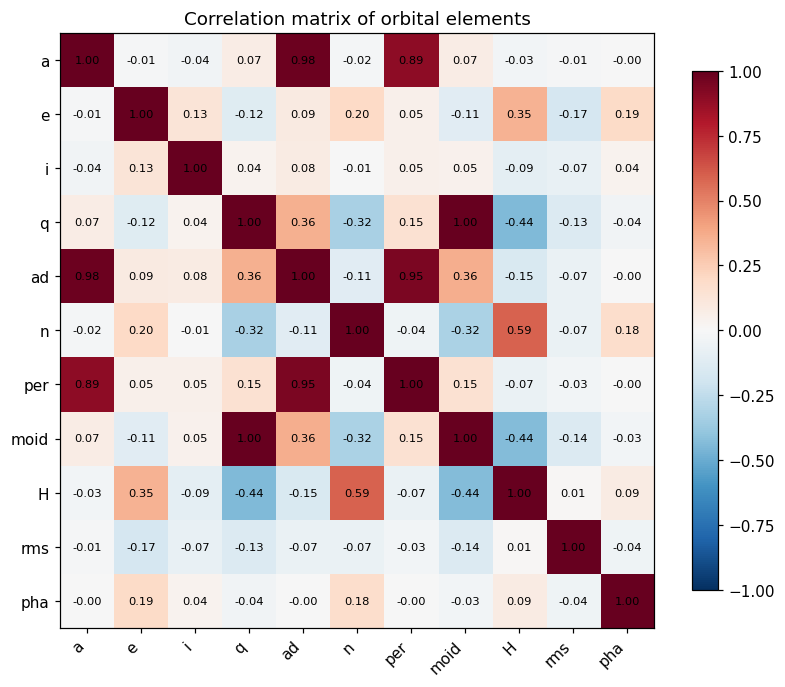

Absolute correlation with the target:
e       0.190
n       0.178
H       0.086
rms     0.041
i       0.036
q       0.036
moid    0.030
ad      0.003
a       0.001
per     0.001
Name: pha, dtype: float64


In [13]:
corr_cols = [c for c in ["a", "e", "i", "q", "ad", "n", "per", "moid", "H", "rms", "pha"]
             if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for a in range(len(corr_cols)):
    for b in range(len(corr_cols)):
        ax.text(b, a, f"{corr.iloc[a, b]:.2f}", ha="center", va="center", fontsize=7.5)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix of orbital elements")
plt.tight_layout()
plt.show()

print("Absolute correlation with the target:")
print(corr["pha"].drop("pha").abs().sort_values(ascending=False).round(3))

Semi-major axis, aphelion distance, orbital period and mean motion are strongly intercorrelated,
as expected from Kepler's third law. All are retained, since the ensemble methods are robust to
collinearity, but the redundancy limits the interpretability of individual Logistic Regression
coefficients reported in Section 9.

---
## 5. Methodology

The workflow applies identical preprocessing, partitioning and evaluation procedures to three
feature sets. All preprocessing is encapsulated within scikit-learn pipelines and fitted only
on training data, both within cross-validation folds and on the final training partition, so
that no information from held-out data influences any fitted transformer.

---
## 6. Outlier analysis, partitioning and preprocessing

**Author: Shunmuka Valsa**

### 6.1 Outlier analysis

In [14]:
spread_cols = [c for c in ["a", "e", "i", "q", "ad", "per", "moid", "H", "rms"] if c in df.columns]
spread = df[spread_cols].describe(percentiles=[0.001, 0.25, 0.5, 0.75, 0.999]).T
display(spread.round(3))

# Eccentricity of at least 1 indicates an unbound trajectory.
if "e" in df.columns:
    hyperbolic = int((df["e"] >= 1).sum())
    print("Records with eccentricity of at least 1:", f"{hyperbolic:,}")
    print("Of which hazardous:", int(df.loc[df["e"] >= 1, "pha"].sum()))

# Extreme value counts under the 1.5 interquartile range criterion.
rows = []
for c in spread_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    far = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    rows.append((c, int(far), round(100 * far / len(df), 2)))
pd.DataFrame(rows, columns=["Column", "Extreme values", "Percent"]) \
    .sort_values("Percent", ascending=False)

,count,mean,std,min,0.1%,25%,50%,75%,99.9%,max
a,150000.0,2.784,38.374,-14702.448,0.897,2.389,2.648,3.003,46.748,1.445322e+03
e,150000.0,0.156,0.093,0.000,0.005,0.092,0.144,0.200,0.781,1.000000e+00
i,150000.0,9.068,6.694,0.011,0.230,4.162,7.430,12.435,42.419,1.728730e+02
q,150000.0,2.400,2.169,0.092,0.410,1.971,2.230,2.581,40.558,4.928700e+01
ad,149999.0,3.363,10.158,0.898,1.118,2.783,3.047,3.365,55.944,2.876079e+03
per,149999.0,2360.445,58501.133,161.160,310.484,1348.401,1574.233,1901.078,116747.190,2.006992e+07
moid,150000.0,1.418,2.167,0.000,0.001,0.979,1.244,1.595,39.567,4.837400e+01
H,148970.0,16.886,1.806,-1.100,6.699,16.000,16.900,17.700,27.800,3.210000e+01
rms,149999.0,0.564,0.100,0.013,0.079,0.522,0.568,0.615,1.008,8.522000e+00


Records with eccentricity of at least 1: 1
Of which hazardous: 0


,Column,Extreme values,Percent
8,rms,7990,5.33
7,H,6344,4.23
4,ad,4784,3.19
2,i,4744,3.16
3,q,4719,3.15
0,a,3990,2.66
1,e,3971,2.65
6,moid,3910,2.61
5,per,3588,2.39


Extreme values are retained. Objects on highly eccentric or inclined orbits are physically
valid rather than erroneous, and such orbits are disproportionately represented among
Earth-approaching objects. Removing them would discard the region of parameter space most
relevant to the classification task. The magnitude of the ranges is instead addressed through
a signed logarithmic transformation followed by standardisation, as described in Section 6.4.

### 6.2 Train and test partitioning

In [15]:
y = df["pha"].values
X = df.drop(columns=["pha"])

# Stratified 80/20 split preserving the class proportion in both partitions.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training partition:", f"{len(X_train):,}", "records,", int(y_train.sum()), "hazardous")
print("Test partition:", f"{len(X_test):,}", "records,", int(y_test.sum()), "hazardous")

Training partition: 120,000 records, 264 hazardous
Test partition: 30,000 records, 66 hazardous


The test partition is reserved for the single evaluation reported in Section 8 and is not used
for model selection, threshold setting or hyperparameter search.

### 6.3 Feature grouping

In [16]:
# Features are grouped by the transformation each requires.

categorical_cols = [c for c in ["neo", "orbit_class"] if c in X.columns]

# Physical measurements, largely incomplete, treated with missingness indicators.
physical_cols = [c for c in ["diameter", "albedo", "diameter_sigma"] if c in X.columns]

# Fields spanning several orders of magnitude, requiring logarithmic compression.
skewed_cols = [c for c in ["a", "ad", "per", "per_y", "n", "moid", "moid_ld", "q", "tp", "epoch"]
               if c in X.columns]

all_numeric = X.select_dtypes(include=[np.number]).columns.tolist()
plain_numeric = [c for c in all_numeric if c not in physical_cols + skewed_cols]

print("Categorical:", categorical_cols)
print("Physical:", physical_cols)
print("Skewed numeric:", skewed_cols)
print("Remaining numeric:", len(plain_numeric), "columns")

Categorical: ['neo', 'orbit_class']
Physical: ['diameter', 'albedo', 'diameter_sigma']
Skewed numeric: ['a', 'ad', 'per', 'per_y', 'n', 'moid', 'moid_ld', 'q', 'tp', 'epoch']
Remaining numeric: 18 columns


### 6.4 Transformation pipelines

In [17]:
def signed_log(arr):
    """Apply a sign-preserving logarithmic compression.

    The standard logarithm is undefined at zero and for negative arguments. Semi-major axis
    takes negative values for unbound orbits, so the transformation is applied to the magnitude
    and the original sign is restored.
    """
    arr = np.asarray(arr, dtype=float)
    return np.sign(arr) * np.log1p(np.abs(arr))


def make_ohe():
    """Instantiate OneHotEncoder with dense output across scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


plain_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

skewed_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(signed_log, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])

# add_indicator appends a binary flag recording whether each value was originally absent.
physical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", make_ohe()),
])

print("Transformation pipelines defined.")

Transformation pipelines defined.


In [18]:
def make_preprocessor(plain, skewed, physical, categorical):
    """Construct a ColumnTransformer, omitting any empty feature group.

    Experiments B and C remove features, which can leave a group empty. Empty column
    specifications are excluded rather than passed to ColumnTransformer.
    """
    parts = []
    if plain:
        parts.append(("plain", plain_pipe, plain))
    if skewed:
        parts.append(("skewed", skewed_pipe, skewed))
    if physical:
        parts.append(("physical", physical_pipe, physical))
    if categorical:
        parts.append(("categorical", categorical_pipe, categorical))
    return ColumnTransformer(parts, remainder="drop")


preprocess = make_preprocessor(plain_numeric, skewed_cols, physical_cols, categorical_cols)

preprocess.fit(X_train.head(20_000))
feature_names = preprocess.get_feature_names_out()
print("Input features:", X_train.shape[1])
print("Transformed features:", len(feature_names))

Input features: 33
Transformed features: 47


In [19]:
pd.DataFrame([
    ("Plain numeric", len(plain_numeric), "Median imputation, standardisation"),
    ("Skewed numeric", len(skewed_cols), "Median imputation, signed log, standardisation"),
    ("Physical", len(physical_cols), "Median imputation with indicator, standardisation"),
    ("Categorical", len(categorical_cols), "Mode imputation, one-hot encoding"),
], columns=["Feature group", "Input columns", "Transformation"])

,Feature group,Input columns,Transformation
0,Plain numeric,18,"Median imputation, standardisation"
1,Skewed numeric,10,"Median imputation, signed log, standardisation"
2,Physical,3,"Median imputation with indicator, standardisation"
3,Categorical,2,"Mode imputation, one-hot encoding"


---
## 7. Model implementation, class imbalance and hyperparameter tuning

**Author: Kunal Sharma**

Three algorithms of differing inductive bias are compared:

- **Logistic Regression**, a linear classifier providing directly interpretable coefficients.
- **Random Forest**, a bagged ensemble capable of representing non-linear decision boundaries
  and providing impurity-based feature importances.
- **Histogram-based Gradient Boosting**, a boosted ensemble designed for large tabular data.

Class imbalance is addressed primarily through balanced class weighting, with SMOTE evaluated
as an alternative in Section 7.2.

In [20]:
def build(model, prep=None):
    """Compose a preprocessing transformer and an estimator into a single pipeline."""
    return Pipeline([("prep", prep if prep is not None else preprocess), ("model", model)])


def fresh_models(prep=None):
    """Return unfitted pipelines for the three candidate algorithms."""
    return {
        "Logistic Regression": build(LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE), prep),
        "Random Forest": build(RandomForestClassifier(
            n_estimators=100, class_weight="balanced", n_jobs=-1,
            random_state=RANDOM_STATE), prep),
        "Hist Gradient Boosting": build(HistGradientBoostingClassifier(
            class_weight="balanced", random_state=RANDOM_STATE), prep),
    }


models = fresh_models()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Stratified 5-fold cross-validation configured.")

Stratified 5-fold cross-validation configured.


### 7.1 Baseline cross-validation

Models are scored by average precision, the area under the precision-recall curve. Under
severe class imbalance, ROC AUC is inflated by the large number of true negatives and is
reported only as a secondary metric.

In [21]:
# Cross-validation and hyperparameter search are performed on a stratified slice of the
# training partition to bound computation time.
if len(X_train) > TUNE_ROWS:
    X_cv, _, y_cv, _ = train_test_split(
        X_train, y_train, train_size=TUNE_ROWS, stratify=y_train, random_state=RANDOM_STATE
    )
else:
    X_cv, y_cv = X_train, y_train

print("Cross-validation set:", f"{len(X_cv):,}", "records,", int(y_cv.sum()), "hazardous")

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_cv, y_cv, cv=cv, scoring="average_precision", n_jobs=1)
    print(f"{name:<25} average precision {scores.mean():.4f} (sd {scores.std():.4f})")

Cross-validation set: 30,000 records, 66 hazardous
Logistic Regression       average precision 0.7975 (sd 0.0789)
Random Forest             average precision 0.9592 (sd 0.0478)
Hist Gradient Boosting    average precision 0.9806 (sd 0.0308)


### 7.2 Comparison of imbalance strategies

SMOTE generates synthetic minority-class observations by interpolation. It is applied within
each training fold only. Applying it prior to partitioning would place synthetic observations
derived from training data into the validation folds, producing optimistically biased estimates.
The `imbalanced-learn` pipeline enforces this ordering.

In [22]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    smote_pipe = ImbPipeline([
        ("prep", preprocess),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    weighted = build(LogisticRegression(max_iter=2000, class_weight="balanced",
                                        random_state=RANDOM_STATE))

    s1 = cross_val_score(smote_pipe, X_cv, y_cv, cv=cv, scoring="average_precision", n_jobs=1)
    s2 = cross_val_score(weighted, X_cv, y_cv, cv=cv, scoring="average_precision", n_jobs=1)
    print(f"Logistic Regression with SMOTE:         {s1.mean():.4f}")
    print(f"Logistic Regression with class weights: {s2.mean():.4f}")
except ImportError:
    print("imbalanced-learn is unavailable; this comparison was not performed.")
    print("Balanced class weighting is applied throughout regardless.")

imbalanced-learn is unavailable; this comparison was not performed.
Balanced class weighting is applied throughout regardless.


### 7.3 Hyperparameter search

Randomised search over a bounded number of parameter combinations is used in place of
exhaustive grid search, which is not tractable at this sample size. Selected configurations
are subsequently refitted on the complete training partition.

In [23]:
search_spaces = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    "Random Forest": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [10, 20],
        "model__min_samples_leaf": [2, 10],
    },
    "Hist Gradient Boosting": {
        "model__learning_rate": [0.03, 0.06, 0.1, 0.2],
        "model__max_iter": [150, 300, 500],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [20, 50],
    },
}
n_iters = {"Logistic Regression": 3, "Random Forest": 3, "Hist Gradient Boosting": 3}

best_params = {}
for name, pipe in models.items():
    search = RandomizedSearchCV(
        pipe, param_distributions=search_spaces[name], n_iter=n_iters[name],
        scoring="average_precision", cv=cv, random_state=RANDOM_STATE, n_jobs=1,
    )
    search.fit(X_cv, y_cv)
    best_params[name] = search.best_params_
    print(f"{name}: average precision {search.best_score_:.4f}")
    print("   ", search.best_params_)

Logistic Regression: average precision 0.8259
    {'model__C': 100.0}
Random Forest: average precision 0.9639
    {'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_depth': 20}
Hist Gradient Boosting: average precision 0.9792
    {'model__min_samples_leaf': 20, 'model__max_iter': 500, 'model__max_depth': None, 'model__learning_rate': 0.03}


In [24]:
# Refit the selected configurations on the complete training partition.
tuned = {}
for name, pipe in models.items():
    final = clone(pipe)
    final.set_params(**best_params[name])
    final.fit(X_train, y_train)
    tuned[name] = final
    print("Refitted:", name)

Refitted: Logistic Regression
Refitted: Random Forest
Refitted: Hist Gradient Boosting


---
## 8. Experiment A: evaluation on the complete feature set

**Author: Madhurishitha Boddu**

Results below constitute the single evaluation of the reserved test partition.

In [25]:
def score_model(name, pipe, X_eval, y_eval):
    """Compute classification metrics for the positive class on held-out data."""
    pred = pipe.predict(X_eval)
    if hasattr(pipe, "predict_proba"):
        prob = pipe.predict_proba(X_eval)[:, 1]
    else:
        prob = pipe.decision_function(X_eval)
    return {
        "Model": name,
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "PR AUC": average_precision_score(y_eval, prob),
        "ROC AUC": roc_auc_score(y_eval, prob),
    }, pred, prob


results, preds, probs = [], {}, {}
for name, pipe in tuned.items():
    row, pred, prob = score_model(name, pipe, X_test, y_test)
    results.append(row)
    preds[name] = pred
    probs[name] = prob

results_A = pd.DataFrame(results).set_index("Model").round(4)
display(results_A)

best_name = results_A["PR AUC"].idxmax()
print("Highest average precision:", best_name)
print(classification_report(y_test, preds[best_name],
                            target_names=["Non-hazardous", "Hazardous"], digits=4))

,Precision,Recall,F1,PR AUC,ROC AUC
Model,,,,,
Logistic Regression,0.4221,0.9848,0.5909,0.6792,0.9993
Random Forest,0.9041,1.0000,0.9496,0.9896,1.0000
Hist Gradient Boosting,0.9412,0.9697,0.9552,0.9949,1.0000


Highest average precision: Hist Gradient Boosting
               precision    recall  f1-score   support

Non-hazardous     0.9999    0.9999    0.9999     29934
    Hazardous     0.9412    0.9697    0.9552        66

     accuracy                         0.9998     30000
    macro avg     0.9706    0.9848    0.9776     30000
 weighted avg     0.9998    0.9998    0.9998     30000



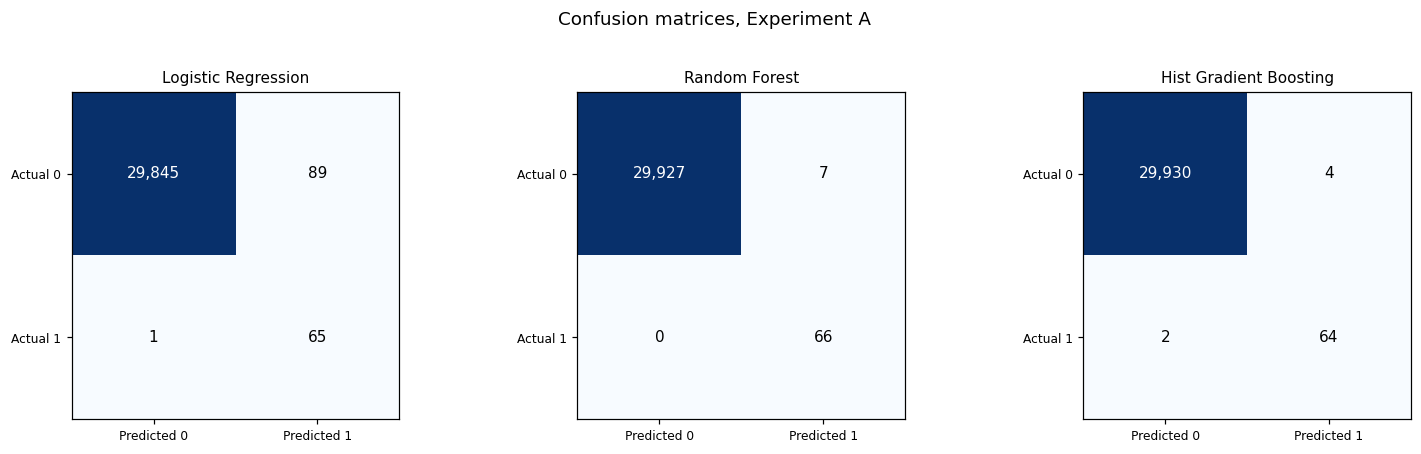

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0, 1], ["Predicted 0", "Predicted 1"], fontsize=8)
    ax.set_yticks([0, 1], ["Actual 0", "Actual 1"], fontsize=8)
    for a in range(2):
        for b in range(2):
            ax.text(b, a, f"{cm[a, b]:,}", ha="center", va="center", fontsize=10,
                    color="white" if cm[a, b] > cm.max() / 2 else "black")
plt.suptitle("Confusion matrices, Experiment A", y=1.02)
plt.tight_layout()
plt.show()

False negatives, shown in the lower-left cell of each matrix, correspond to hazardous objects
classified as non-hazardous. In a planetary defence context the cost of a false negative
substantially exceeds that of a false positive, which argues for operating at a threshold
favouring recall over precision.

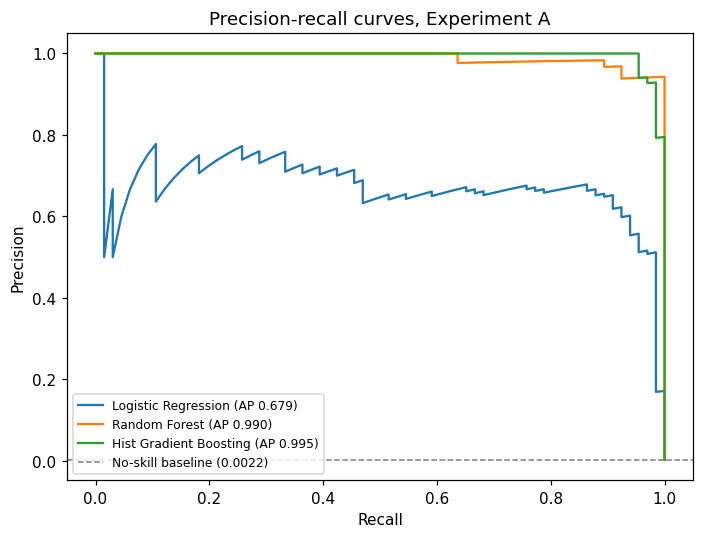

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, prob in probs.items():
    p, r, _ = precision_recall_curve(y_test, prob)
    ax.plot(r, p, label=f"{name} (AP {average_precision_score(y_test, prob):.3f})")

chance = y_test.mean()
ax.axhline(chance, ls="--", color="grey", lw=1, label=f"No-skill baseline ({chance:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves, Experiment A")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

---
## 9. Feature importance and Experiment B

**Author: Kunal Sharma**

### 9.1 Feature importance

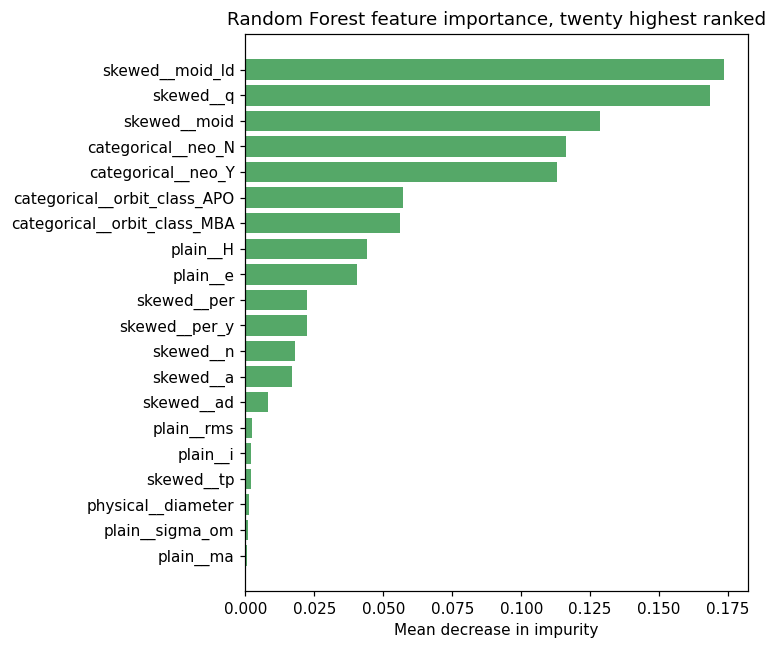

skewed__moid_ld                 0.1735
skewed__q                       0.1684
skewed__moid                    0.1287
categorical__neo_N              0.1164
categorical__neo_Y              0.1129
categorical__orbit_class_APO    0.0571
categorical__orbit_class_MBA    0.0560
plain__H                        0.0442
plain__e                        0.0405
skewed__per                     0.0223
skewed__per_y                   0.0223
skewed__n                       0.0182
skewed__a                       0.0168
skewed__ad                      0.0082
plain__rms                      0.0023
plain__i                        0.0022
skewed__tp                      0.0021
physical__diameter              0.0013
plain__sigma_om                 0.0011
plain__ma                       0.0007
dtype: float64

In [28]:
rf = tuned["Random Forest"]
top = pd.Series(
    rf.named_steps["model"].feature_importances_,
    index=rf.named_steps["prep"].get_feature_names_out(),
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index[::-1], top.values[::-1], color="#55a868")
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest feature importance, twenty highest ranked")
plt.tight_layout()
plt.show()

top.round(4)

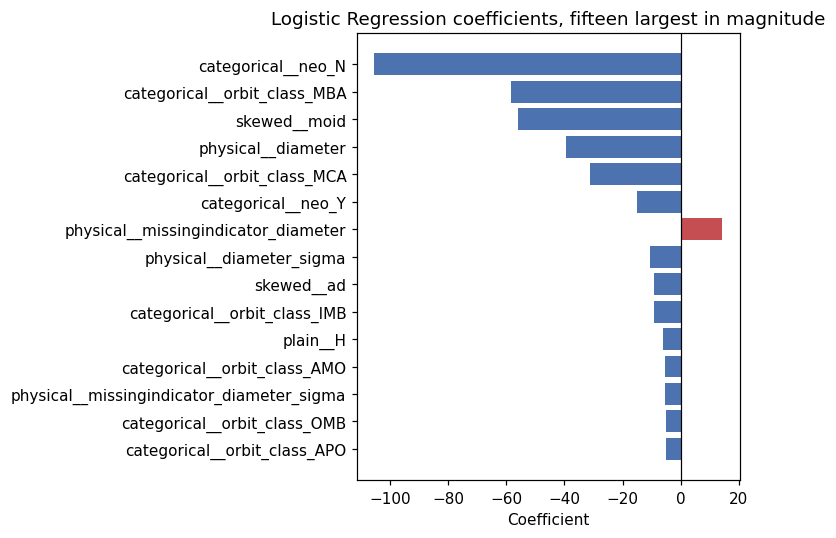

In [29]:
# Logistic Regression coefficients on standardised features. Positive values increase the
# predicted probability of the hazardous class.
lr = tuned["Logistic Regression"]
coefs = pd.Series(lr.named_steps["model"].coef_[0],
                  index=lr.named_steps["prep"].get_feature_names_out())
strongest = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in strongest.values[::-1]]
ax.barh(strongest.index[::-1], strongest.values[::-1], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient")
ax.set_title("Logistic Regression coefficients, fifteen largest in magnitude")
plt.tight_layout()
plt.show()

### 9.2 Experiment B: excluding the defining parameters

The JPL criterion is defined on minimum orbit intersection distance and absolute magnitude,
both present in the catalogue. High performance in Experiment A therefore demonstrates
recovery of a deterministic threshold rule rather than an empirical relationship. Experiment B
removes `moid`, `moid_ld` (an alternative unit representation of the same quantity) and `H`.
Hyperparameters selected in Section 7.3 are reused.

In [30]:
leak_B = [c for c in ["moid", "moid_ld", "H"] if c in X.columns]
print("Excluded features:", leak_B)

X_train_B = X_train.drop(columns=leak_B)
X_test_B = X_test.drop(columns=leak_B)

prep_B = make_preprocessor(
    [c for c in plain_numeric if c not in leak_B],
    [c for c in skewed_cols if c not in leak_B],
    [c for c in physical_cols if c not in leak_B],
    categorical_cols,
)

rows_B = []
for name, pipe in fresh_models(prep_B).items():
    pipe.set_params(**best_params[name])
    pipe.fit(X_train_B, y_train)
    row, _, _ = score_model(name, pipe, X_test_B, y_test)
    rows_B.append(row)
    print("Fitted:", name)

results_B = pd.DataFrame(rows_B).set_index("Model").round(4)
display(results_B)

Excluded features: ['moid', 'moid_ld', 'H']
Fitted: Logistic Regression
Fitted: Random Forest
Fitted: Hist Gradient Boosting


,Precision,Recall,F1,PR AUC,ROC AUC
Model,,,,,
Logistic Regression,0.0902,1.0000,0.1654,0.2633,0.9953
Random Forest,0.3311,0.7576,0.4608,0.3846,0.9975
Hist Gradient Boosting,0.3032,0.8636,0.4488,0.3712,0.9826


---
## 10. Experiment C: orbital elements in isolation

**Author: Shunmuka Valsa**

Experiment B retains `orbit_class` and `neo`. Both are defined with reference to proximity to
Earth: the Apollo, Aten and Amor classes denote Earth-crossing or Earth-approaching orbits, and
every potentially hazardous asteroid is by definition a near-Earth object. These fields
therefore encode the target criterion indirectly. Experiment C removes them in addition to the
parameters excluded in Experiment B, leaving only orbital elements and physical measurements
that are not defined relative to Earth.

In [31]:
leak_C = leak_B + categorical_cols
print("Excluded features:", leak_C)

X_train_C = X_train.drop(columns=leak_C)
X_test_C = X_test.drop(columns=leak_C)

# No categorical features remain, which make_preprocessor accommodates by omitting the group.
prep_C = make_preprocessor(
    [c for c in plain_numeric if c not in leak_C],
    [c for c in skewed_cols if c not in leak_C],
    [c for c in physical_cols if c not in leak_C],
    [],
)
print("Retained features:", X_train_C.shape[1])

Excluded features: ['moid', 'moid_ld', 'H', 'neo', 'orbit_class']
Retained features: 28


In [32]:
rows_C = []
for name, pipe in fresh_models(prep_C).items():
    pipe.set_params(**best_params[name])
    pipe.fit(X_train_C, y_train)
    row, _, _ = score_model(name, pipe, X_test_C, y_test)
    rows_C.append(row)
    print("Fitted:", name)

results_C = pd.DataFrame(rows_C).set_index("Model").round(4)
display(results_C)

Fitted: Logistic Regression
Fitted: Random Forest
Fitted: Hist Gradient Boosting


,Precision,Recall,F1,PR AUC,ROC AUC
Model,,,,,
Logistic Regression,0.0954,1.0000,0.1741,0.2426,0.9948
Random Forest,0.3571,0.7576,0.4854,0.4073,0.9977
Hist Gradient Boosting,0.3032,0.8636,0.4488,0.3712,0.9826


---
## 11. Comparative results

**Author: Madhurishitha Boddu**

Precision  Recall      F1  \
Experiment               Model                                               
A: all features          Logistic Regression        0.4221  0.9848  0.5909   
                         Random Forest              0.9041  1.0000  0.9496   
                         Hist Gradient Boosting     0.9412  0.9697  0.9552   
B: excluding moid and H  Logistic Regression        0.0902  1.0000  0.1654   
                         Random Forest              0.3311  0.7576  0.4608   
                         Hist Gradient Boosting     0.3032  0.8636  0.4488   
C: orbital elements only Logistic Regression        0.0954  1.0000  0.1741   
                         Random Forest              0.3571  0.7576  0.4854   
                         Hist Gradient Boosting     0.3032  0.8636  0.4488   

                                                 PR AUC  ROC AUC  
Experiment               Model                                    
A: all features          Logistic Regression     0.6792   0.9993  
                         Random Forest           0.9896   1.0000  
                         Hist Gradient Boosting  0.9949   1.0000  
B: excluding moid and H  Logistic Regression     0.2633   0.9953  
                         Random Forest           0.3846   0.9975  
                         Hist Gradient Boosting  0.3712   0.9826  
C: orbital elements only Logistic Regression     0.2426   0.9948  
                         Random Forest           0.4073   0.9977  
                         Hist Gradient Boosting  0.3712   0.9826

,A: all features,B: excluding moid and H,C: orbital elements only
Model,,,
Logistic Regression,0.6792,0.2633,0.2426
Random Forest,0.9896,0.3846,0.4073
Hist Gradient Boosting,0.9949,0.3712,0.3712


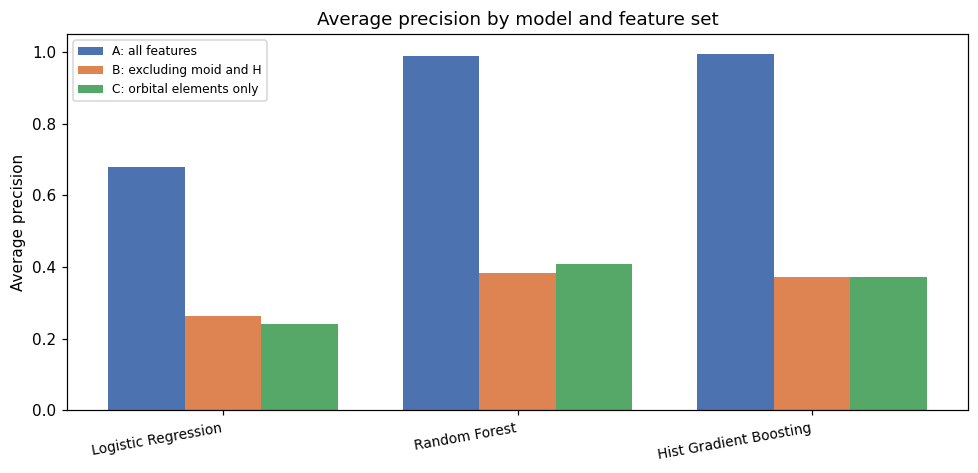

Reduction from Experiment A to B:
Model
Logistic Regression       0.4159
Random Forest             0.6050
Hist Gradient Boosting    0.6237
dtype: float64
Reduction from Experiment A to C:
Model
Logistic Regression       0.4366
Random Forest             0.5823
Hist Gradient Boosting    0.6237
dtype: float64


In [33]:
comparison = pd.concat(
    [results_A, results_B, results_C],
    keys=["A: all features", "B: excluding moid and H", "C: orbital elements only"],
    names=["Experiment", "Model"],
)
display(comparison)

summary = pd.DataFrame({
    "A: all features": results_A["PR AUC"],
    "B: excluding moid and H": results_B["PR AUC"],
    "C: orbital elements only": results_C["PR AUC"],
}).round(4)
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(summary))
w = 0.26
for k, (label, colour) in enumerate(zip(summary.columns, ["#4c72b0", "#dd8452", "#55a868"])):
    ax.bar(x + (k - 1) * w, summary[label], w, label=label, color=colour)
ax.set_xticks(x, summary.index, rotation=10, ha="right", fontsize=9)
ax.set_ylabel("Average precision")
ax.set_ylim(0, 1.05)
ax.set_title("Average precision by model and feature set")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Reduction from Experiment A to B:")
print((summary["A: all features"] - summary["B: excluding moid and H"]).round(4))
print("Reduction from Experiment A to C:")
print((summary["A: all features"] - summary["C: orbital elements only"]).round(4))

---
## 12. Conclusions and limitations

**Author: Leonardo Rodrigues Fabbro**

### 12.1 Findings

All three algorithms achieve near-perfect discrimination on the complete feature set. This
result is definitional rather than substantive: minimum orbit intersection distance and
absolute magnitude are the quantities on which the JPL criterion is specified, and the models
recover the corresponding threshold rule.

Withholding these parameters in Experiment B reduces average precision substantially, from
0.9949 to 0.3712 for Histogram Gradient Boosting. Experiment C, which additionally removes
`orbit_class` and `neo`, produces results that are nearly identical to Experiment B, and Random
Forest performance increases slightly (0.3846 to 0.4073). This indicates that the categorical
fields carried no information beyond that already present in the orbital elements, which is
consistent with dynamical class being derived from semi-major axis, eccentricity and perihelion
distance. The predictive signal recovered in Experiments B and C is therefore attributable to
orbital geometry rather than to categorical proxies for Earth proximity.

The ensemble methods retain more performance than Logistic Regression as features are withdrawn,
indicating that the residual relationship between orbital geometry and hazard designation is
not well approximated by a linear decision boundary.

### 12.2 Model selection

Histogram Gradient Boosting is selected as the best-performing model. It achieves the highest
average precision on the complete feature set (0.9949, against 0.9896 for Random Forest and
0.6792 for Logistic Regression) and matches Random Forest under the reduced feature sets while
training in seconds rather than minutes. Random Forest attains marginally higher average
precision in Experiment C (0.4073 against 0.3712), so the two ensemble methods are comparable
once the defining parameters are withheld. Logistic Regression is not competitive in any
condition, indicating that the relationship between orbital parameters and hazard designation
is not linearly separable.

### 12.3 Limitations

- Perihelion distance and semi-major axis jointly constrain the minimum separation between an
  object's orbit and Earth's. Experiment C therefore removes the precomputed quantity but not
  the geometry from which it derives.
- The catalogue reflects observational selection. Small and low-albedo objects are
  systematically underrepresented, so the models partly encode survey bias rather than
  population characteristics.
- Physical measurements are absent for the majority of records. Missingness indicators mitigate
  this but also act as a proxy for prior observational attention.
- Results derive from a single stratified partition. Repetition across multiple random seeds
  would permit interval estimates.
- Hyperparameters were selected under Experiment A and reused in Experiments B and C, which may
  understate the achievable performance of the reduced feature sets.
- The test partition contains 66 positive observations. Positive-class metrics are therefore
  computed on a small sample and are subject to substantial variability, with each observation
  representing approximately 1.5 percentage points of recall.
- Models were trained on a stratified subsample of the catalogue for computational tractability.

### 12.4 Further work

Decision thresholds were left at the default of 0.5. Given the asymmetric cost structure of
planetary defence applications, threshold selection targeting a specified recall level would
be a more appropriate operating criterion.

---
## 13. Contribution summary

| Author | Sections | Implementation |
|---|---|---|
| Leonardo Rodrigues Fabbro | 3, 12 | Dataset loading and schema verification, data dictionary, removal of identifier and redundant date fields, target resolution and encoding, duplicate detection, completeness assessment, stratified subsampling, conclusions and limitations |
| Madhurishitha Boddu | 4, 8| Class distribution analysis, distributional comparison of orbital parameters by class, hazard prevalence by dynamical class, correlation analysis, evaluation function, test-set metrics, confusion matrices, precision-recall curves, comparative results |
| Shunmuka Valsa | 6, 10 | Outlier analysis, stratified partitioning, feature grouping, signed logarithmic transformation, imputation with missingness indicators, one-hot encoding, standardisation, ColumnTransformer construction, Experiment C |
| Kunal Sharma | 7, 9 | Model pipeline construction, balanced class weighting, SMOTE evaluation within folds, stratified 5-fold cross-validation, randomised hyperparameter search, refitting on the full training partition, feature importance analysis, Experiment B |

All members contributed to the proposal, attended project meetings, and participate in the
presentation.

### Deviations from the approved proposal

1. The completeness assessment was reassigned from M. Boddu to L. Rodrigues Fabbro, alongside
   the remaining dataset documentation tasks.
2. Outlier analysis was added to the preprocessing responsibilities of S. Valsa.
3. Experiment C was added and assigned to S. Valsa. The proposal specified two experiments;
   Experiment B alone retains `orbit_class` and `neo`, which encode the target criterion
   indirectly, so a third condition was required for a valid test.